In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# EDA

New reviews have too little influence on a listing's position in search. The goal is a model of `P(Y=1|X)` - the probability that a viewed listing is booked within 24h - to be used as part of the ranking.

The question here is whether the available data makes that feasible:

- How much information do `sessions`, `reviews` and `listings` actually hold? What is lost once missing values are dropped?

- What can be extracted from the comment text (VADER sentiment analysis)?

This notebook is exploration only. Cleaning and sentiment analysis happen in `01-preprocessing.ipynb`.

## Loading the raw data

In [2]:
reviews_df = pd.read_csv("../data/raw/reviews.csv")
sessions_df = pd.read_csv("../data/raw/sessions.csv")
listings_df = pd.read_csv("../data/raw/listings.csv")

In [3]:
reviews_df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,5.068454e+06,NaN,NaN,NaN,Ethan,NaN
1,1.892001e+07,1.125276e+18,2024-04-01,NaN,Martin,A great location for our first visit to Copenh...
2,1.309641e+07,1.666708e+08,2017-07-04,32939959.0,NaN,Rune was awesome! The place was in a good loca...
3,7.344462e+17,8.151277e+17,2023-01-29,18789303.0,James,Line was great for checking in and checking ou...
4,NaN,1.115075e+18,2024-03-18,562500349.0,Jules,"Cozy studio at 20 min from the city center, co..."


In [4]:
sessions_df.head()

,action,user_id,timestamp,listing_id,booking_date,booking_duration,booking_id
0,browse_listings,22786874.0,2020-03-26T09:10:44.742016,NaN,NaN,NaN,NaN
1,view_listing,22786874.0,2020-03-26T09:46:03.742016,40780623.0,NaN,NaN,NaN
2,view_listing,NaN,NaN,5068454.0,NaN,NaN,NaN
3,book_listing,22786874.0,2020-03-26T09:46:03.742016,NaN,2020-08-15,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,9.294375e+17,https://www.nocarz.pl/rooms/929437466908063114,2.025093e+13,2025-09-30,previous scrape,Spacious Nørrebro apartment,"Spacious, colourful and family-friendly Maison...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,2263296.0,...,NaN,5.00,NaN,NaN,f,NaN,NaN,NaN,0.0,0.18
1,1.470415e+18,https://www.nocarz.pl/rooms/1470415126062480123,2.025093e+13,2025-09-30,previous scrape,Centralt beliggende og hyggelig.,You'll have a great time here. Centrally locat...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,708758407.0,...,5.00,5.00,NaN,NaN,f,1.0,1.0,0.0,0.0,1.50
2,9.347605e+17,https://www.nocarz.pl/rooms/934760500908785664,2.025093e+13,NaN,city scrape,Cozy & central home in trendy area,My apartment includes a bedroom with a queensi...,"The location is one of the best in Copenhagen,...",https://a0.muscache.com/pictures/hosting/Hosti...,1645772.0,...,4.94,4.94,4.88,NaN,f,1.0,1.0,0.0,0.0,0.60
3,5.980420e+05,https://www.nocarz.pl/rooms/598042,2.025093e+13,2025-09-29,city scrape,NaN,"Nice flat on the top floor in Vesterbro, Copen...",Vesterbro is a fairly young area with a sea of...,https://a0.muscache.com/pictures/1dca74d3-7334...,2242384.0,...,4.90,4.95,4.70,NaN,NaN,1.0,1.0,0.0,0.0,NaN
4,NaN,https://www.nocarz.pl/rooms/1389150402776230880,NaN,NaN,city scrape,Bold 3-Room Apartment in Valby,"Enjoy a stylish stay in this cozy home, conven...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,371936500.0,...,4.50,4.63,4.50,NaN,NaN,2.0,1.0,1.0,0.0,NaN


## Table preview

In [6]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91660 entries, 0 to 91659
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     73429 non-null  float64
 1   id             73227 non-null  float64
 2   date           73275 non-null  str    
 3   reviewer_id    73216 non-null  float64
 4   reviewer_name  73431 non-null  str    
 5   comments       73160 non-null  str    
dtypes: float64(3), str(3)
memory usage: 4.2 MB


In [7]:
reviews_df.describe(include="all")

,listing_id,id,date,reviewer_id,reviewer_name,comments
count,7.342900e+04,7.322700e+04,73275,7.321600e+04,73431,73160
unique,NaN,NaN,4217,NaN,17097,72364
top,NaN,NaN,2025-08-31,NaN,Anna,.
freq,NaN,NaN,234,NaN,476,89
mean,3.485372e+17,8.059348e+17,NaN,1.670079e+08,NaN,NaN
std,4.850847e+17,5.527307e+17,NaN,1.765854e+08,NaN,NaN
min,2.350000e+04,5.910800e+04,NaN,4.520000e+02,NaN,NaN
25%,1.384305e+07,6.128673e+08,NaN,2.914014e+07,NaN,NaN
50%,3.900050e+07,9.454967e+17,NaN,9.389412e+07,NaN,NaN
75%,8.093455e+17,1.256446e+18,NaN,2.523785e+08,NaN,NaN


In [8]:
sessions_df.describe(include="all")

,action,user_id,timestamp,listing_id,booking_date,booking_duration,booking_id
count,992194,9.922920e+05,991468,9.192390e+05,73466,73351,76184
unique,4,NaN,862151,NaN,4571,4550,73782
top,view_listing,NaN,2023-07-14T01:11:22.364672,NaN,2024-05-22,2025-04-30,9c3c96c1-6857-4746-884c-845343431854
freq,842390,NaN,3,NaN,77,80,2
mean,NaN,1.675754e+08,NaN,6.442887e+17,NaN,NaN,NaN
std,NaN,1.770833e+08,NaN,5.723778e+17,NaN,NaN,NaN
min,NaN,4.520000e+02,NaN,2.350000e+04,NaN,NaN,NaN
25%,NaN,2.913214e+07,NaN,3.247928e+07,NaN,NaN,NaN
50%,NaN,9.430837e+07,NaN,7.180179e+17,NaN,NaN,NaN
75%,NaN,2.533066e+08,NaN,1.169477e+18,NaN,NaN,NaN


In [9]:
sessions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240104 entries, 0 to 1240103
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   action            992194 non-null  str    
 1   user_id           992292 non-null  float64
 2   timestamp         991468 non-null  str    
 3   listing_id        919239 non-null  float64
 4   booking_date      73466 non-null   str    
 5   booking_duration  73351 non-null   str    
 6   booking_id        76184 non-null   str    
dtypes: float64(2), str(5)
memory usage: 66.2 MB


In [10]:
print(listings_df.columns.to_list())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [11]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4598 entries, 0 to 4597
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3646 non-null   float64
 1   listing_url                                   3683 non-null   str    
 2   scrape_id                                     3657 non-null   float64
 3   last_scraped                                  3709 non-null   str    
 4   source                                        3697 non-null   str    
 5   name                                          3698 non-null   str    
 6   description                                   3612 non-null   str    
 7   neighborhood_overview                         1258 non-null   str    
 8   picture_url                                   3665 non-null   str    
 9   host_id                                       3667 non-null   float64
 10 

## Column selection

Before looking at distributions, we decide which listing columns are worth analysing at all. For every `Listings` column we measure its predictive strength against the label `Y` (a booking within 24h of viewing the listing).

**Why run this analysis only on `Listings`?**

- **`Sessions`** is behavioural event data. We use only the event keys: `action`, `user_id`, `timestamp`, `listing_id` - and from them we build the label `Y` itself. The remaining columns (`booking_date`, `booking_duration`, `booking_id`) describe the consequence of a booking, which is what we are predicting - at view time they do not exist yet.
- **`Reviews`** holds only `listing_id`, `date` and `comments`. The only real content is the comment text, which we convert into sentiment features anyway (VADER in `01-preprocessing`). There are no ready-made candidate columns to select from.
- **`Listings`**, by contrast, has ~75 columns of wildly varying usefulness - property type, host data, statistics snapshots. This is where the decision has to be made.

Below we compute ROC-AUC for **every** `Listings` column and flag which ones carry **leakage** (a snapshot from the future).

Y is built here only AS A HELPER (the same 24h logic as in 02), purely for this analysis - it is never saved.


In [12]:
# Columns that are a snapshot from a scrape taken AFTER the sessions => leakage (the future relative to the event).
LEAKY = {
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'number_of_reviews', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'number_of_reviews_ly', 'reviews_per_month',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'availability_eoy', 'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'first_review', 'last_review', 'has_availability', 'calendar_last_scraped',
    'last_scraped', 'calendar_updated',
}

In [13]:
def _coerce_num(s):
    """Generic string -> number converter (one mechanism for every column):
    1. 't'/'f' -> 1/0,
    2. a number with an optional currency/percent/short unit: '$1,098.00' -> 1098.0, '95%' -> 95, '1 bath' -> 1.
    Free text, URLs and dates (YYYY-MM-DD) stay non-numeric - there the digits are
    part of the text rather than a quantity.
    """
    null_tokens = ['nan', 'none', '', 'n/a', 'na', '<na>', 'null', '-']

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors='coerce')

    low = s.astype(str).str.strip().str.lower()
    valid = s.notna() & ~low.isin(null_tokens)
    sub = low[valid]

    if len(sub) == 0:
        return pd.Series(np.nan, index=s.index)
    if sub.isin(['t', 'f', 'true', 'false']).mean() > 0.8:                 # bool
        return low.where(valid).map({'t': 1.0, 'true': 1.0, 'f': 0.0, 'false': 0.0})

    cleaned = sub.str.replace(r'[$,]', '', regex=True)
    if cleaned.str.match(r'^\d+\.?\d*\s*[a-z.%]*$').mean() > 0.8:
        full = low.where(valid).str.replace(r'[$,]', '', regex=True)
        return pd.to_numeric(full.str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
    return pd.Series(np.nan, index=s.index)


In [14]:
from sklearn.metrics import roc_auc_score

sessions_df['user_id'] = pd.to_numeric(sessions_df['user_id'], errors='coerce').astype('Int64')
sessions_df['listing_id'] = pd.to_numeric(sessions_df['listing_id'], errors='coerce').astype('Int64')
sessions_df['timestamp'] = pd.to_datetime(sessions_df['timestamp'], errors='coerce')
listings_df['id'] = pd.to_numeric(listings_df['id'], errors='coerce').astype('Int64')

sessions = (sessions_df[sessions_df['action'].isin(['view_listing', 'book_listing'])]
       .dropna(subset=['user_id', 'listing_id', 'timestamp']).drop_duplicates())
views = (sessions[sessions['action'] == 'view_listing'][['user_id', 'timestamp', 'listing_id']]
         .sort_values('timestamp'))
bookings = (sessions[sessions['action'] == 'book_listing'][['user_id', 'listing_id', 'timestamp']]
          .rename(columns={'timestamp': 'booking_timestamp'}).sort_values('booking_timestamp'))

sessions_with_target = pd.merge_asof(views, bookings, left_on='timestamp', right_on='booking_timestamp',
                     by=['user_id', 'listing_id'], direction='forward',
                     tolerance=pd.Timedelta(hours=24))
sessions_with_target['Y'] = sessions_with_target['booking_timestamp'].notna().astype(int)

listings = listings_df.rename(columns={'id': 'listing_id'})
merged_df = sessions_with_target[['listing_id', 'Y']].merge(listings, on='listing_id', how='inner')
yv = merged_df['Y'].to_numpy()
base_rate = yv.mean()
print(f"'Views' z 'booking': {len(merged_df):,}  |  Y=1: {base_rate * 100:.2f}%")

'Views' z 'booking': 317,277  |  Y=1: 0.73%


In [15]:
ID_COLS = {'id', 'host_id', 'scrape_id', 'license'}
rows = []
for col in listings.columns:
    if col in ('listing_id', 'Y'):
        continue
    s = merged_df[col]
    miss = s.isna().mean()
    role, auc, reason = None, np.nan, ''
    if col in ID_COLS or 'url' in col:
        role = 'pominieta'
        reason = 'URL' if 'url' in col else 'identyfikator'
    else:
        x = _coerce_num(s)
        if x.notna().mean() >= 0.05 and x.nunique(dropna=True) >= 2:
            role = 'numeryczna'
            xv = x.to_numpy(dtype=float)
            m = ~np.isnan(xv)
            a = roc_auc_score(yv[m], xv[m])
            auc = max(a, 1 - a)
        else:
            nun = s.nunique(dropna=True)
            if 2 <= nun <= 50:
                role = 'kategoria (target-enc)'
                enc = s.fillna('__NA__')
                means = pd.Series(yv, index=enc.index).groupby(enc).transform('mean')
                a = roc_auc_score(yv, means.to_numpy())
                auc = max(a, 1 - a)
            else:
                role = 'pominieta'
                reason = 'stala (brak wariancji)' if nun < 2 else f'tekst / wysoka kardynalnosc ({nun})'
    rows.append(dict(kolumna=col, rola=role, leaky=col in LEAKY, braki_pct=miss * 100, auc=auc, powod=reason))

report = pd.DataFrame(rows).sort_values(['leaky', 'auc'], ascending=[True, False], na_position='last')

pd.set_option('display.max_rows', None)
pd.set_option('display.width', 160)
print(f"Bazowa czestosc Y=1: {base_rate:.4f}  (AUC ~0.5 = brak sygnalu)\n")
print("auc = max(AUC, 1-AUC); kategorie liczone przez target-encoding (wartosc orientacyjna)\n")
print(report[['kolumna', 'rola', 'leaky', 'braki_pct', 'auc', 'powod']]
      .to_string(index=False, float_format=lambda v: f'{v:7.3f}' if isinstance(v, float) else str(v)))

Bazowa czestosc Y=1: 0.0073  (AUC ~0.5 = brak sygnalu)

auc = max(AUC, 1-AUC); kategorie liczone przez target-encoding (wartosc orientacyjna)

                                     kolumna                   rola  leaky  braki_pct     auc                              powod
                        host_acceptance_rate             numeryczna  False     36.426   0.614                                   
                           host_is_superhost             numeryczna  False     20.642   0.612                                   
                               neighbourhood kategoria (target-enc)  False     72.435   0.606                                   
                      minimum_maximum_nights             numeryczna  False     19.696   0.592                                   
                      maximum_maximum_nights             numeryczna  False     20.414   0.588                                   
                          host_neighbourhood kategoria (target-enc)  False     82.6

In [16]:
# Are the *_nights variants redundant?
nights_cols = ['minimum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
               'minimum_nights_avg_ntm', 'maximum_nights', 'minimum_maximum_nights',
               'maximum_maximum_nights', 'maximum_nights_avg_ntm']
nights = listings_df[nights_cols].apply(pd.to_numeric, errors='coerce')

print("Korelacja Pearsona z minimum_nights (polityka MIN-stay):")
print(nights.corr()['minimum_nights'].drop('minimum_nights').sort_values(ascending=False).round(3).to_string())
print("\nKorelacja Pearsona z minimum_maximum_nights (polityka MAX-stay):")
print(nights.corr()['minimum_maximum_nights'].drop('minimum_maximum_nights').sort_values(ascending=False).round(3).to_string())


Korelacja Pearsona z minimum_nights (polityka MIN-stay):
minimum_nights_avg_ntm    0.984
maximum_minimum_nights    0.972
minimum_minimum_nights    0.774
maximum_nights            0.012
minimum_maximum_nights    0.012
maximum_maximum_nights    0.006
maximum_nights_avg_ntm    0.005

Korelacja Pearsona z minimum_maximum_nights (polityka MAX-stay):
maximum_nights_avg_ntm    0.999
maximum_maximum_nights    0.998
maximum_nights            0.747
maximum_minimum_nights    0.021
minimum_nights_avg_ntm    0.015
minimum_nights            0.012
minimum_minimum_nights    0.004


### Findings, and the leakage problem

The `Listings` columns fall into three groups:

- **Leaking (`leaky=True`)** - a snapshot from the 2025-09 scrape, i.e. the state **after** the sessions: `review_scores_*`, `number_of_reviews*`, `availability_*`, `estimated_*`, and the `first/last_review` dates. They look strongest (`number_of_reviews` AUC ~0.83), but they describe the future relative to the listing view and are unavailable at real inference time. **They are dropped.**
- **Non-leaking** - attributes known before the event. The strongest: `host_acceptance_rate` (~0.61), `host_is_superhost` (~0.61), and the `*_nights` policy (~0.57-0.59).
- **Skipped** - URLs, identifiers, free text (`amenities`), constant columns (`license`, `neighbourhood_group_cleansed`).

**Why VADER instead of the ready-made `review_scores_*`?** Those scores are an aggregated snapshot from the future (leakage). The review signal is therefore computed from the comment text with [VADER](https://github.com/cjhutto/vaderSentiment), point-in-time (`D+1` visibility, in `02-feature_engineering`).

**What we take:**

- the basic listing attributes: `property_type`, `room_type`, `accommodates`, `bathrooms`, `bedrooms`, `price`, `neighbourhood_cleansed` (rare `property_type` -> `"Other"`),
- `host_is_superhost` and `host_acceptance_rate` - the strongest non-leaking features,
- `minimum_nights` and `minimum_maximum_nights` - one representative from each of the two independent stay-policy families, which also score well (correlation shown above).

Columns with very high missingness are skipped despite good AUC (`neighbourhood` ~72%, `host_neighbourhood` ~83%).


## Type conversion

Applying the decisions above so the distributions can be inspected (the actual cleaning happens in `01-preprocessing.ipynb`).

In [17]:
sessions_df = sessions_df[["action", "user_id", "timestamp", "listing_id"]]
reviews_df = reviews_df[["listing_id", "date", "comments"]]
listing_df = listings_df[['id', 'property_type', 'room_type', 'accommodates',
                          'bathrooms_text', 'bedrooms', 'price', 'neighbourhood_cleansed',
                          'host_is_superhost', 'host_acceptance_rate',
                          'minimum_nights', 'minimum_maximum_nights']].copy()
listing_df = listing_df.rename(columns={'id': 'listing_id'})

In [ ]:
# Reviews
reviews_df["listing_id"] = reviews_df["listing_id"].astype("Int64")
reviews_df['date'] = pd.to_datetime(reviews_df['date'])

# Sessions
sessions_df["user_id"] = sessions_df["user_id"].astype("Int64")
sessions_df["listing_id"] = sessions_df["listing_id"].astype("Int64")
sessions_df['timestamp'] = pd.to_datetime(sessions_df['timestamp'])

# Listings
listings_df['id'] = listings_df['id'].astype('Int64')
listings_df["accommodates"] = listings_df["accommodates"].astype("Int64")
listings_df["bedrooms"] = listings_df["bedrooms"].astype("Int64")

listing_df['host_is_superhost'] = listing_df['host_is_superhost'].map({'t': 'Yes', 'f': 'No'})
listing_df['price'] = _coerce_num(listing_df['price'])
listing_df['bathrooms'] = _coerce_num(listing_df['bathrooms_text'])
listing_df['host_acceptance_rate'] = _coerce_num(listing_df['host_acceptance_rate'])
listing_df = listing_df.drop(columns=['bathrooms_text'])

freq = listing_df['property_type'].value_counts()
rare_types = freq[freq < 30].index
listing_df['property_type'] = listing_df['property_type'].where(
    ~listing_df['property_type'].isin(rare_types), other='Other'
)

print(f"Oferty po przygotowaniu: {len(listing_df)}")
print(f"Kategorie property_type: {listing_df['property_type'].nunique()}")
print(f"host_is_superhost: {listing_df['host_is_superhost'].value_counts(dropna=False).to_dict()}")
for col in ['price', 'bathrooms', 'host_acceptance_rate', 'minimum_nights', 'minimum_maximum_nights']:
    print(f"{col}: mediana={listing_df[col].median():.0f}, braki={listing_df[col].isna().mean()*100:.0f}%")

Oferty po przygotowaniu: 4598
Kategorie property_type: 8
host_is_superhost: {'No': 3163, nan: 939, 'Yes': 496}
price: mediana=1200, braki=52%
bathrooms: mediana=1, braki=21%
host_acceptance_rate: mediana=74, braki=37%
minimum_nights: mediana=3, braki=21%
minimum_maximum_nights: mediana=120, braki=20%


## Distributions of the key attributes

Distributions of actions, sessions, reviews and the basic listing attributes. The most important thing is coverage across tables: if a listing appears in a session but is absent from `Listings`, we cannot build a complete feature vector for it.

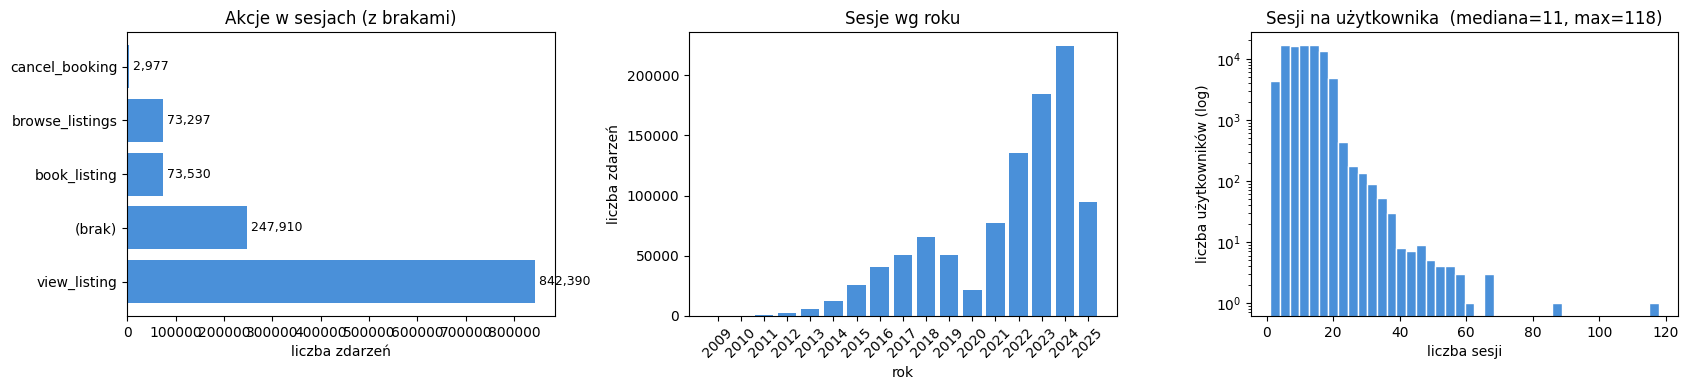

Sesji łącznie: 1,240,104
Unikalnych użytkowników: 90,113
Unikalnych ofert w sesjach: 17,322
Zakres dat: 2009-09-13 – 2025-09-08


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

act_counts = sessions_df['action'].fillna('(brak)').value_counts()
ax = axes[0]
labels = [str(x) for x in act_counts.index]
ax.barh(labels, act_counts.values, color='#4a90d9')
ax.set_title('Akcje w sesjach (z brakami)')
ax.set_xlabel('liczba zdarzeń')
for i, v in enumerate(act_counts.values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)

sess_time = sessions_df.dropna(subset=['timestamp']).copy()
sess_time['year'] = sess_time['timestamp'].dt.year.astype(int)
year_counts = sess_time['year'].value_counts().sort_index()
ax = axes[1]
ax.bar([str(y) for y in year_counts.index], year_counts.values, color='#4a90d9')
ax.set_title('Sesje wg roku')
ax.set_xlabel('rok')
ax.set_ylabel('liczba zdarzeń')
ax.tick_params(axis='x', rotation=45)

spu = sessions_df.dropna(subset=['user_id']).groupby('user_id').size()
ax = axes[2]
ax.hist(spu, bins=40, color='#4a90d9', edgecolor='white')
ax.set_yscale('log')
ax.set_title(f'Sesji na użytkownika  (mediana={spu.median():.0f}, max={spu.max()})')
ax.set_xlabel('liczba sesji')
ax.set_ylabel('liczba użytkowników (log)')

plt.tight_layout()
plt.show()

print(f"Sesji łącznie: {len(sessions_df):,}")
print(f"Unikalnych użytkowników: {sessions_df['user_id'].nunique():,}")
print(f"Unikalnych ofert w sesjach: {sessions_df['listing_id'].nunique():,}")
print(f"Zakres dat: {sess_time['timestamp'].min().date()} – {sess_time['timestamp'].max().date()}")

Sessions:

- `view_listing` dominates; `book_listing` is far rarer.
- `browse_listings` has no `listing_id`, so it cannot be used for a per-listing model.
- The data spans 2009-2025, but most events fall in the recent years.
- A typical user has on the order of a dozen or so sessions.

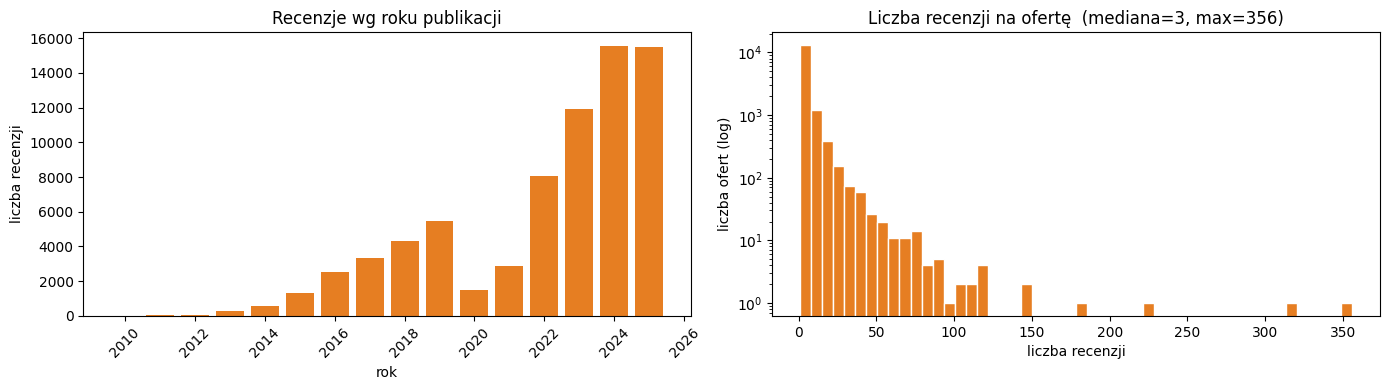

Recenzji z poprawnym listing_id: 73,429
Unikalnych ofert recenzowanych: 15,037
Mediana / średnia recenzji na ofertę: 3 / 4.9
% ofert z >=5 recenzjami: 29.3%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

r_time = reviews_df.dropna(subset=['date']).copy()
r_time['year'] = r_time['date'].dt.year
yc = r_time['year'].value_counts().sort_index()
ax = axes[0]
ax.bar(yc.index.astype(int), yc.values, color='#e67e22')
ax.set_title('Recenzje wg roku publikacji')
ax.set_xlabel('rok')
ax.set_ylabel('liczba recenzji')
ax.tick_params(axis='x', rotation=45)

rpl = reviews_df.dropna(subset=['listing_id']).groupby('listing_id').size()
ax = axes[1]
ax.hist(rpl, bins=50, color='#e67e22', edgecolor='white')
ax.set_yscale('log')
ax.set_title(f'Liczba recenzji na ofertę  (mediana={rpl.median():.0f}, max={rpl.max()})')
ax.set_xlabel('liczba recenzji')
ax.set_ylabel('liczba ofert (log)')

plt.tight_layout()
plt.show()

print(f"Recenzji z poprawnym listing_id: {len(reviews_df.dropna(subset=['listing_id'])):,}")
print(f"Unikalnych ofert recenzowanych: {rpl.size:,}")
print(f"Mediana / średnia recenzji na ofertę: {rpl.median():.0f} / {rpl.mean():.1f}")
print(f"% ofert z >=5 recenzjami: {(rpl >= 5).mean()*100:.1f}%")

Pokrycie z tabelą Listings (snapshot):
  Unikalnych ofert w sesjach:      17,322
  Unikalnych ofert w Listings:      3,646
  Część wspólna:                    3,646

  % wszystkich sesji dot. ofert z Listings:        68.8%
  % view_listing dot. ofert z Listings:            73.6%
  % recenzji dot. ofert z Listings:                15.1%
  Unikalnych ofert recenzowanych w Listings:        2,353 / 3,646


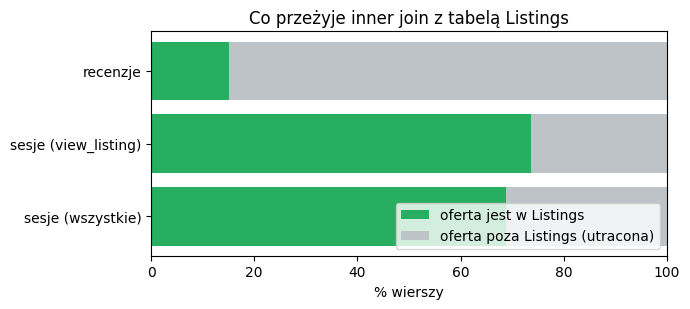

In [21]:
listings_ids = set(listings_df['id'].dropna().astype('Int64').unique())

sess_clean = sessions_df.dropna(subset=['listing_id'])
sess_in_listings = sess_clean['listing_id'].astype('Int64').isin(listings_ids)
view_clean = sess_clean[sess_clean['action'] == 'view_listing']
view_in_listings = view_clean['listing_id'].astype('Int64').isin(listings_ids)

rev_clean = reviews_df.dropna(subset=['listing_id'])
rev_in_listings = rev_clean['listing_id'].astype('Int64').isin(listings_ids)

print("Pokrycie z tabelą Listings (snapshot):")
print(f"  Unikalnych ofert w sesjach:     {sess_clean['listing_id'].nunique():>7,}")
print(f"  Unikalnych ofert w Listings:    {len(listings_ids):>7,}")
print(
    f"  Część wspólna:                  {len(set(sess_clean['listing_id'].astype('Int64').unique()) & listings_ids):>7,}")
print()
print(f"  % wszystkich sesji dot. ofert z Listings:       {sess_in_listings.mean()*100:5.1f}%")
print(f"  % view_listing dot. ofert z Listings:           {view_in_listings.mean()*100:5.1f}%")
print(f"  % recenzji dot. ofert z Listings:               {rev_in_listings.mean()*100:5.1f}%")
print(
    f"  Unikalnych ofert recenzowanych w Listings:      {rev_clean[rev_in_listings]['listing_id'].nunique():>7,} / {len(listings_ids):,}")

fig, ax = plt.subplots(1, 1, figsize=(7, 3.2))
labels = ['sesje (wszystkie)', 'sesje (view_listing)', 'recenzje']
in_pct = [sess_in_listings.mean()*100, view_in_listings.mean()*100, rev_in_listings.mean()*100]
out_pct = [100-p for p in in_pct]
ax.barh(labels, in_pct, color='#27ae60', label='oferta jest w Listings')
ax.barh(labels, out_pct, left=in_pct, color='#bdc3c7', label='oferta poza Listings (utracona)')
ax.set_xlim(0, 100)
ax.set_xlabel('% wierszy')
ax.legend(loc='lower right')
ax.set_title('Co przeżyje inner join z tabelą Listings')
plt.tight_layout()
plt.show()


Reviews and cross-table coverage:

- The median is 3 reviews per listing, so for many listings there is little text to work with.
- Sessions contain far more unique listings than `Listings` does. `Listings` looks like a snapshot of currently active offers.
- After joining with `Listings`, about 74% of `view_listing` events survive, but only about 12% of reviews belong to listings present in `Listings`.
- This limits how much review information actually reaches the model.

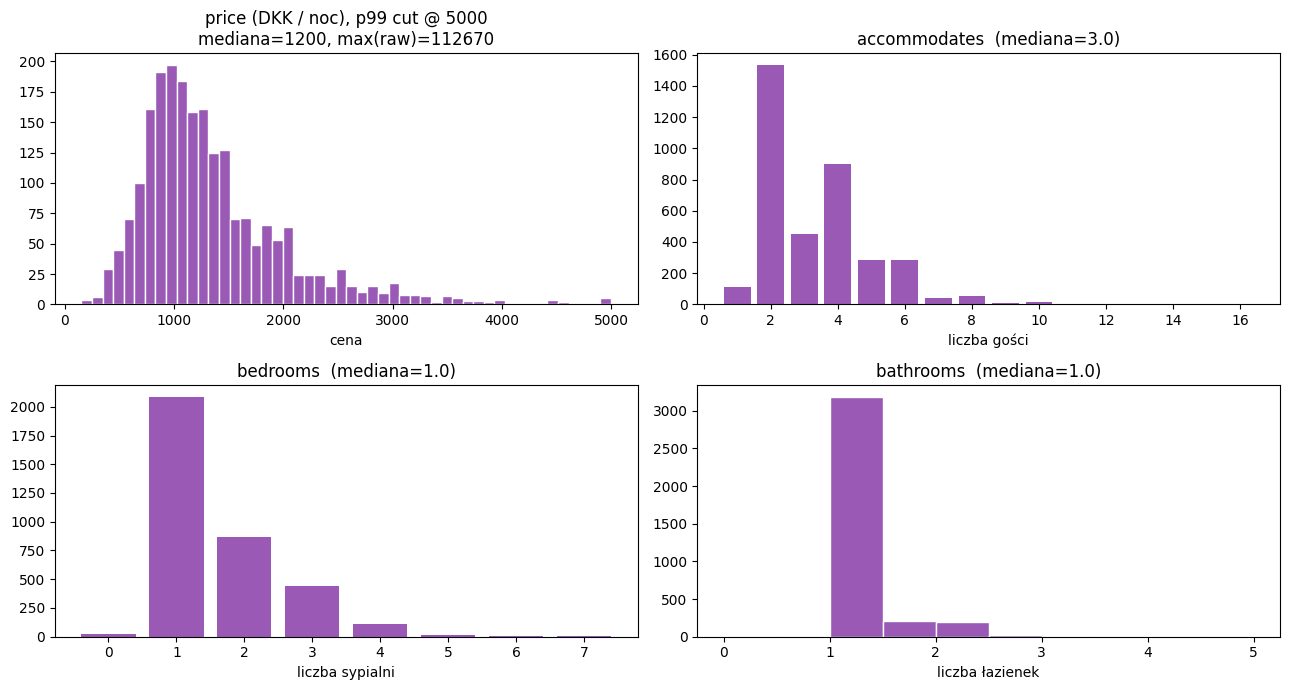

Outliery cenowe: max(raw) = 112670, p99 = 5000, p99.9 = 20550
Liczba ofert z ceną > 10k: 6  (0.27%)


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# price (clipped at p99)
price = listing_df['price'].dropna()
p99 = price.quantile(0.99)
ax = axes[0, 0]
ax.hist(price[price <= p99].to_numpy(), bins=50, color='#9b59b6', edgecolor='white')
ax.set_title(f'price (DKK / noc), p99 cut @ {p99:.0f}\nmediana={price.median():.0f}, max(raw)={price.max():.0f}')
ax.set_xlabel('cena')

# accommodates
ax = axes[0, 1]
ac = listing_df['accommodates'].dropna().astype(int).value_counts().sort_index()
ax.bar(np.asarray(ac.index, dtype=int), ac.values, color='#9b59b6')
ax.set_title(f'accommodates  (mediana={listing_df["accommodates"].median()})')
ax.set_xlabel('liczba gości')

# bedrooms
ax = axes[1, 0]
bd = listing_df['bedrooms'].dropna().astype(int).value_counts().sort_index()
ax.bar(np.asarray(bd.index, dtype=int), bd.values, color='#9b59b6')
ax.set_title(f'bedrooms  (mediana={listing_df["bedrooms"].median()})')
ax.set_xlabel('liczba sypialni')

# bathrooms
ax = axes[1, 1]
ba = listing_df['bathrooms'].dropna().to_numpy()
ax.hist(ba, bins=int(ba.max())*2 if ba.max() > 0 else 10, color='#9b59b6', edgecolor='white')
ax.set_title(f'bathrooms  (mediana={listing_df["bathrooms"].median()})')
ax.set_xlabel('liczba łazienek')

plt.tight_layout()
plt.show()

print(f"Outliery cenowe: max(raw) = {price.max():.0f}, p99 = {p99:.0f}, p99.9 = {price.quantile(0.999):.0f}")
print(f"Liczba ofert z ceną > 10k: {(price > 10000).sum()}  ({(price > 10000).mean()*100:.2f}%)")


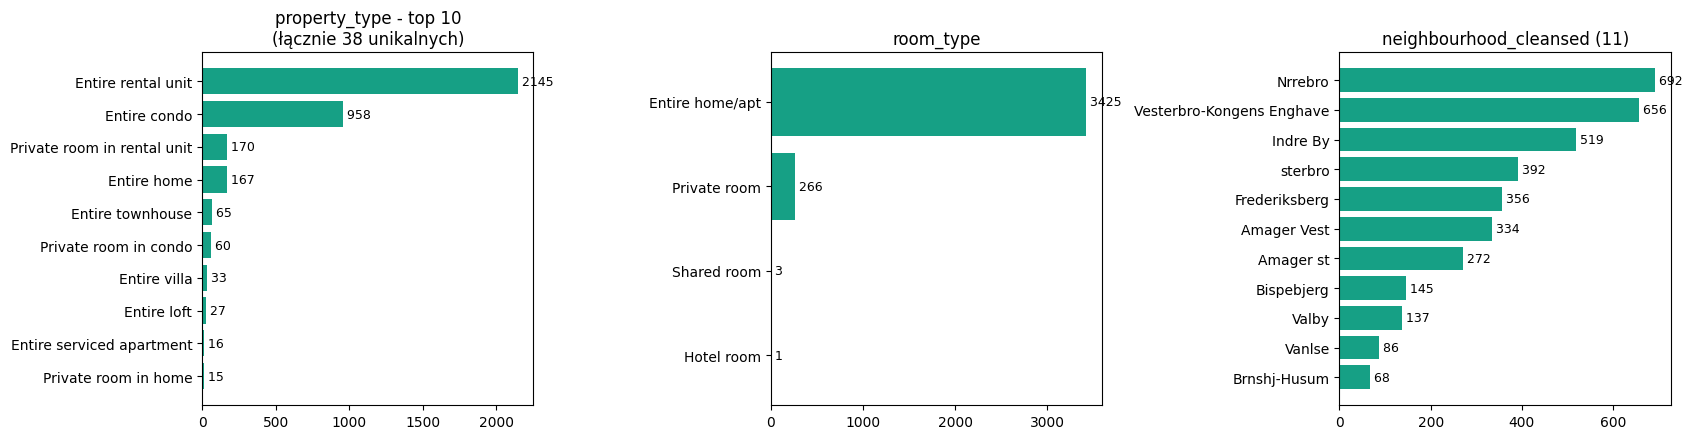

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# property_type raw distribution (before grouping rare values into Other)
pt = listings_df['property_type'].dropna().value_counts()
ax = axes[0]
top = pt.head(10)
ax.barh([str(x) for x in top.index[::-1]], top.values[::-1], color='#16a085')
ax.set_title(f'property_type - top 10\n(łącznie {pt.size} unikalnych)')
for i, v in enumerate(top.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

# room_type
rt = listings_df['room_type'].dropna().value_counts()
ax = axes[1]
ax.barh([str(x) for x in rt.index[::-1]], rt.values[::-1], color='#16a085')
ax.set_title('room_type')
for i, v in enumerate(rt.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

# neighbourhood
nb = listings_df['neighbourhood_cleansed'].dropna().value_counts()
ax = axes[2]
ax.barh([str(x) for x in nb.index[::-1]], nb.values[::-1], color='#16a085')
ax.set_title(f'neighbourhood_cleansed ({nb.size})')
for i, v in enumerate(nb.values[::-1]):
    ax.text(v, i, f' {v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

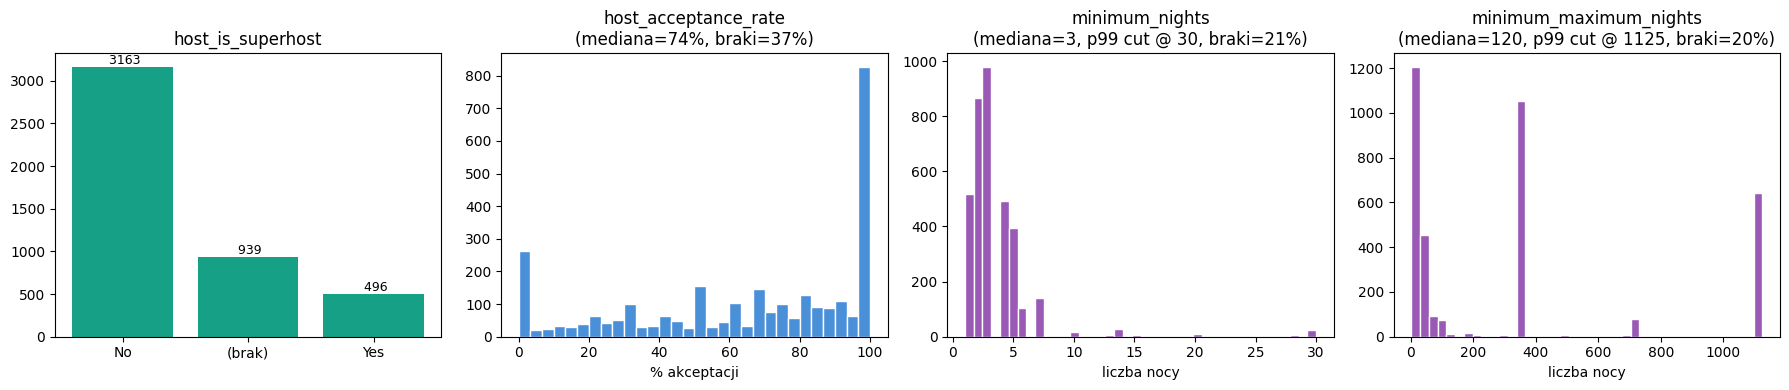

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# host_is_superhost (Yes/No/missing)
sh = listing_df['host_is_superhost'].fillna('(brak)').value_counts()
axes[0].bar([str(x) for x in sh.index], sh.values, color='#16a085')
axes[0].set_title('host_is_superhost')
for i, v in enumerate(sh.values):
    axes[0].text(i, v, f' {v}', ha='center', va='bottom', fontsize=9)

# host_acceptance_rate (%)
har = listing_df['host_acceptance_rate'].dropna()
axes[1].hist(har.to_numpy(), bins=30, color='#4a90d9', edgecolor='white')
axes[1].set_title(f'host_acceptance_rate\n(mediana={har.median():.0f}%, braki={listing_df["host_acceptance_rate"].isna().mean()*100:.0f}%)')
axes[1].set_xlabel('% akceptacji')

# minimum_nights (clipped at p99)
for ax, col in zip(axes[2:], ['minimum_nights', 'minimum_maximum_nights']):
    v = listing_df[col].dropna()
    clip = v.quantile(0.99)
    ax.hist(v[v <= clip].to_numpy(), bins=40, color='#9b59b6', edgecolor='white')
    ax.set_title(f'{col}\n(mediana={v.median():.0f}, p99 cut @ {clip:.0f}, braki={listing_df[col].isna().mean()*100:.0f}%)')
    ax.set_xlabel('liczba nocy')

plt.tight_layout()
plt.show()

Static listing attributes:

- Price has a long tail with a few very high values.
- Most offers are entire flats or houses, and `property_type` has a few frequent categories and many rare ones.

## Missing values

The scale of missingness in the columns that matter for the model. The actual dropping and filling happens in `01-preprocessing.ipynb`.

### Sessions (`sessions.csv`)

From `sessions` we use `action`, `user_id`, `timestamp`, `listing_id`. The remaining columns (`booking_date`, `booking_duration`, `booking_id`) describe booked stays and do not enter the conversion model.

In [25]:
print(f"Braki action: {sessions_df['action'].isnull().sum()}")
print(f"Braki timestamp: {sessions_df['timestamp'].isnull().sum()}")
print(f'Braki user_id: {sessions_df["user_id"].isnull().sum()}')

print()

print(f'Brak listing_id w view_listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "view_listing")).sum()}')
print(f'Brak listing_id w book_listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "book_listing")).sum()}')
print(f"Poprawny listing_id w book_listing: {((sessions_df['action'] == 'book_listing') & (~sessions_df['listing_id'].isnull())).sum()}")

print()

print(f'Brak user_id i timestamp: {(sessions_df["timestamp"].isnull() & sessions_df["user_id"].isnull()).sum()}')
print(f'Brak timestamp i listing_id: {(sessions_df["timestamp"].isnull() & sessions_df["listing_id"].isnull()).sum()}')
print(f'Brak user_id i listing_id: {(sessions_df["listing_id"].isnull() & sessions_df["user_id"].isnull()).sum()}')


Braki action: 247910
Braki timestamp: 248636
Braki user_id: 247812

Brak listing_id w view_listing: 168070
Brak listing_id w book_listing: 14828
Poprawny listing_id w book_listing: 58702

Brak user_id i timestamp: 49737
Brak timestamp i listing_id: 64543
Brak user_id i listing_id: 63849


There are many missing values. In preprocessing we drop rows without `timestamp`, `user_id`, `action` or `listing_id`, because without them a booking cannot be matched to a specific listing view.

### Reviews (`reviews.csv`)

In [26]:
print(f"Braki listing_id: {reviews_df['listing_id'].isnull().sum()}")
print(f"Braki date: {reviews_df['date'].isnull().sum()}")
print(f'Braki comments: {reviews_df["comments"].isnull().sum()}')


Braki listing_id: 18231
Braki date: 18385
Braki comments: 18500


Missing values appear in `listing_id` (~18k), `date` (~18k) and `comments` (~19k). Each of these columns is essential: without them a review cannot be attached to a listing, placed in time, or scored for sentiment.

### Listings (`listings.csv`)

We keep the features chosen in the analysis (listing attributes + host + stay policy). Checking missingness in `listing_df` - price, bedrooms, bathrooms, and the newly added host and `*_nights` features.


In [27]:
print("Braki w wybranych kolumnach oferty:")
print(listing_df.isnull().sum())
print(f"\nLiczba ofert łącznie: {len(listing_df)}")


Braki w wybranych kolumnach oferty:
listing_id                 952
property_type              884
room_type                  903
accommodates               904
bedrooms                  1048
price                     2400
neighbourhood_cleansed     941
host_is_superhost          939
host_acceptance_rate      1687
minimum_nights             948
minimum_maximum_nights     922
bathrooms                  965
dtype: int64

Liczba ofert łącznie: 4598


Missing `bedrooms`, `bathrooms` and `price` are imputed during feature engineering, so that whole listings are not lost.

## Conclusions

- The problem is heavily **imbalanced** - only ~0.73% of views end in a booking within 24h, so accuracy is useless; the right metrics are ROC-AUC and Average Precision.
- `Listings` is a **snapshot of currently active offers** - only about 74% of `view_listing` events and about 12% of reviews join to it, so for some sessions a complete feature vector cannot be built.
- There are few reviews per listing (median 3), so recent-review features will be available for only part of the observations.
- **The strongest single features are contaminated by leakage** (`number_of_reviews` AUC ~0.83, `estimated_*`, `review_scores_*`) - they are a snapshot from the future, so they are dropped despite the high AUC.
- Among the **non-leaking** features, the best are host attributes (`host_acceptance_rate`, `host_is_superhost`, ~0.61) and the stay policy (`*_nights`, ~0.57-0.59) - which is why they were added to the feature set.
- The signal ceiling is low: even the best non-leaking features reach only AUC ~0.6, and the basic listing attributes (`price`, `accommodates`) sit near 0.5 - so the model will be a **ranking component** rather than a hard classifier. There is signal in the listing features nonetheless.
- The newly added features have **moderate missingness** (~20-37%), imputed during feature engineering so that listings are not lost.
- The following notebooks check whether, despite these limitations, the review features differ between bookings and non-bookings.
